<a href="https://colab.research.google.com/github/rohit1308/google_collab_ML/blob/main/sgd2409.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
housing = fetch_california_housing(as_frame=True)

In [ ]:
housing

{'data':        MedInc  HouseAge  AveRooms  ...  AveOccup  Latitude  Longitude
 0      8.3252      41.0  6.984127  ...  2.555556     37.88    -122.23
 1      8.3014      21.0  6.238137  ...  2.109842     37.86    -122.22
 2      7.2574      52.0  8.288136  ...  2.802260     37.85    -122.24
 3      5.6431      52.0  5.817352  ...  2.547945     37.85    -122.25
 4      3.8462      52.0  6.281853  ...  2.181467     37.85    -122.25
 ...       ...       ...       ...  ...       ...       ...        ...
 20635  1.5603      25.0  5.045455  ...  2.560606     39.48    -121.09
 20636  2.5568      18.0  6.114035  ...  3.122807     39.49    -121.21
 20637  1.7000      17.0  5.205543  ...  2.325635     39.43    -121.22
 20638  1.8672      18.0  5.329513  ...  2.123209     39.43    -121.32
 20639  2.3886      16.0  5.254717  ...  2.616981     39.37    -121.24
 
 [20640 rows x 8 columns],
 'target': 0        4.526
 1        3.585
 2        3.521
 3        3.413
 4        3.422
          ...  
 2063

In [ ]:
X = housing.data
y = housing.target

In [ ]:
X.shape

(20640, 8)

In [ ]:
y.head()

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [ ]:
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


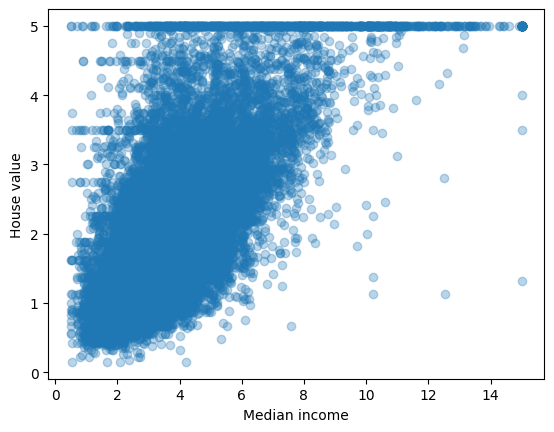

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X["MedInc"], y, alpha=0.3)

plt.xlabel("Median income")
plt.ylabel("House value")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
linear_model = LinearRegression()

In [ ]:
linear_model.fit(
    X_train_scaled,
    y_train
)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
predictions = linear_model.predict(X_test_scaled)

In [ ]:
rmse = mean_squared_error(y_test, predictions) ** 0.5

In [ ]:
rmse

0.7455813830127763

In [ ]:
from sklearn.linear_model import SGDRegressor

In [ ]:
model = SGDRegressor(
    loss="squared_error",
    learning_rate="adaptive",
    eta0=0.001,
    max_iter=35,
    random_state=42
)

In [ ]:
model.fit(X_train_scaled, y_train)

SGDRegressor(eta0=0.001, learning_rate='adaptive', max_iter=35, random_state=42)

In [ ]:
predictions = model.predict(X_test_scaled)

In [ ]:
rmse = mean_squared_error(y_test, predictions) ** 0.5
rmse

44.25889893293108

In [ ]:
import numpy as np
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error


def train_model(X, y, batch_size, learning_rate, epochs):

    model = SGDRegressor(
        loss="squared_error",
        learning_rate="constant",
        eta0=learning_rate,
        random_state=42
    )

    losses = []

    n = len(X)

    for epoch in range(epochs):

        # Shuffle the training data
        indices = np.random.permutation(n)

        X_shuffled = X[indices]
        y_shuffled = y.iloc[indices].to_numpy()

        # Go through batches
        for start in range(0, n, batch_size):

            end = start + batch_size

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            model.partial_fit(
                X_batch,
                y_batch
            )

        # Measure loss on the whole training set
        predictions = model.predict(X)

        loss = mean_squared_error(
            y,
            predictions
        )

        losses.append(loss)

    return model, losses

In [ ]:
sgd_model, sgd_losses = train_model(
    X_train_scaled,
    y_train,
    batch_size=1,
    learning_rate=0.001,
    epochs=20
)

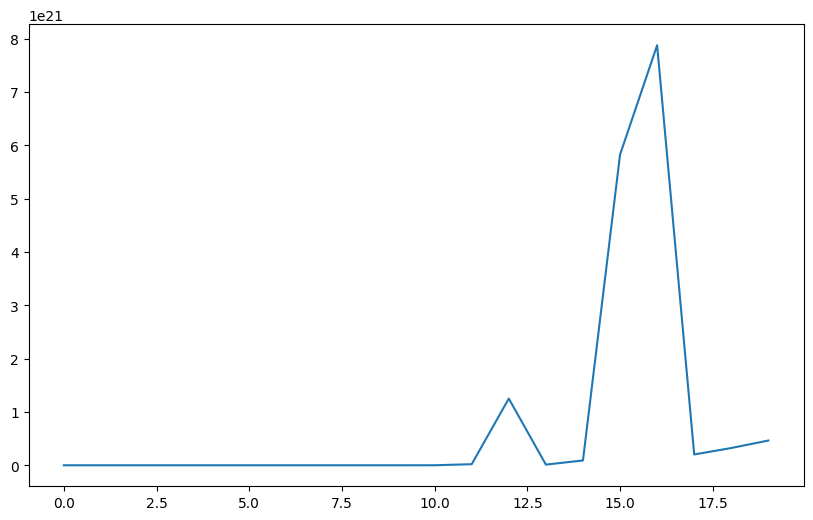

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    sgd_losses,
    label="SGD (batch size = 1)"
)

plt.show()